# Clustering Work Arrangements by Productivity, Well-Being, and Work–Life Balance

**Team Members:** Batoul Hamieh - Samira Jawish - Jana Tarabay

### Study Rationale: 
Given the absence of predefined labels, this study employs clustering to reveal latent employee profiles shaped by productivity, mental and physical well-being, and work–life balance, and to examine how these profiles align with onsite, remote, and hybrid work arrangements in the post-pandemic era.

### Dataset Description

- **Title:** post_pandemic_remote_work_health_impact_2025  
- **Source:** Kaggle  
- **Collection Period:** 2025  
- **Unit of Analysis:** Individual employees 

### Exploartory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

#Setting to make numbers easier to read on display
pd.options.display.float_format='{:20.2f}'.format

#Show all columns on output
pd.set_option('display.max_columns',999)

In [2]:
df = pd.read_csv("post_pandemic_remote_work_health_impact_2025.csv")

In [3]:
df.head()

,Survey_Date,Age,Gender,Region,Industry,Job_Role,Work_Arrangement,Hours_Per_Week,Mental_Health_Status,Burnout_Level,Work_Life_Balance_Score,Physical_Health_Issues,Social_Isolation_Score,Salary_Range
0,2025-06-01,27,Female,Asia,Professional Services,Data Analyst,Onsite,64,Stress Disorder,High,3,Shoulder Pain; Neck Pain,2,$40K-60K
1,2025-06-01,37,Female,Asia,Professional Services,Data Analyst,Onsite,37,Stress Disorder,High,4,Back Pain,2,$80K-100K
2,2025-06-01,32,Female,Africa,Education,Business Analyst,Onsite,36,ADHD,High,3,Shoulder Pain; Eye Strain,2,$80K-100K
3,2025-06-01,40,Female,Europe,Education,Data Analyst,Onsite,63,ADHD,Medium,1,Shoulder Pain; Eye Strain,2,$60K-80K
4,2025-06-01,30,Male,South America,Manufacturing,DevOps Engineer,Hybrid,65,NaN,Medium,5,NaN,4,$60K-80K


In [4]:
df.shape

(3157, 14)

In [5]:
df.columns

Index(['Survey_Date', 'Age', 'Gender', 'Region', 'Industry', 'Job_Role',
       'Work_Arrangement', 'Hours_Per_Week', 'Mental_Health_Status',
       'Burnout_Level', 'Work_Life_Balance_Score', 'Physical_Health_Issues',
       'Social_Isolation_Score', 'Salary_Range'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3157 entries, 0 to 3156
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Survey_Date              3157 non-null   object
 1   Age                      3157 non-null   int64 
 2   Gender                   3157 non-null   object
 3   Region                   3157 non-null   object
 4   Industry                 3157 non-null   object
 5   Job_Role                 3157 non-null   object
 6   Work_Arrangement         3157 non-null   object
 7   Hours_Per_Week           3157 non-null   int64 
 8   Mental_Health_Status     2358 non-null   object
 9   Burnout_Level            3157 non-null   object
 10  Work_Life_Balance_Score  3157 non-null   int64 
 11  Physical_Health_Issues   2877 non-null   object
 12  Social_Isolation_Score   3157 non-null   int64 
 13  Salary_Range             3157 non-null   object
dtypes: int64(4), object(10)
memory usage: 34

**Columns Detected with Null Values:**  
- Mental_Health_Status 
- Physical_Health_Issues  

In [7]:
df.describe()

,Age,Hours_Per_Week,Work_Life_Balance_Score,Social_Isolation_Score
count,3157.00,3157.00,3157.00,3157.00
mean,43.73,49.90,3.00,2.70
std,12.66,8.90,1.16,1.19
min,22.00,35.00,1.00,1.00
25%,33.00,42.00,2.00,2.00
50%,44.00,50.00,3.00,3.00
75%,55.00,57.00,4.00,4.00
max,65.00,65.00,5.00,5.00


**Observations:**
- Ordinal variables (1-5): "Work_Life_Balance_Score", "Social_Isolation_Score"
 
- numerical variables: "Age"(22–65), "Hours_Per_Week"(35–65)

- Needs scaling



In [8]:
df.describe(include='O')

,Survey_Date,Gender,Region,Industry,Job_Role,Work_Arrangement,Mental_Health_Status,Burnout_Level,Physical_Health_Issues,Salary_Range
count,3157,3157,3157,3157,3157,3157,2358,3157,2877,3157
unique,26,4,6,9,24,3,6,3,31,5
top,2025-06-07,Male,South America,Professional Services,Research Scientist,Onsite,PTSD,Medium,Shoulder Pain; Eye Strain,$60K-80K
freq,137,1535,575,730,151,1562,423,1366,262,1014


In [9]:
df["Physical_Health_Issues"].unique()

array(['Shoulder Pain; Neck Pain', 'Back Pain',
       'Shoulder Pain; Eye Strain', nan, 'Back Pain; Shoulder Pain',
       'Back Pain; Shoulder Pain; Wrist Pain', 'Neck Pain',
       'Shoulder Pain', 'Eye Strain; Wrist Pain', 'Back Pain; Eye Strain',
       'Back Pain; Shoulder Pain; Eye Strain', 'Back Pain; Wrist Pain',
       'Shoulder Pain; Eye Strain; Neck Pain; Wrist Pain', 'Eye Strain',
       'Back Pain; Shoulder Pain; Eye Strain; Neck Pain',
       'Eye Strain; Neck Pain', 'Shoulder Pain; Eye Strain; Wrist Pain',
       'Back Pain; Neck Pain', 'Wrist Pain',
       'Back Pain; Shoulder Pain; Neck Pain',
       'Back Pain; Eye Strain; Neck Pain',
       'Back Pain; Shoulder Pain; Eye Strain; Wrist Pain',
       'Shoulder Pain; Eye Strain; Neck Pain', 'Neck Pain; Wrist Pain',
       'Back Pain; Eye Strain; Neck Pain; Wrist Pain',
       'Back Pain; Eye Strain; Wrist Pain',
       'Back Pain; Neck Pain; Wrist Pain', 'Shoulder Pain; Wrist Pain',
       'Back Pain; Shoulder Pain; Ey

**Observation:**  
- "Physical_Health_Issues": 31 unique values (multiple conditions concatenated with semicolons.)
- Requires preprocessing

In [10]:
df["Mental_Health_Status"].unique()

array(['Stress Disorder', 'ADHD', nan, 'Burnout', 'Anxiety', 'PTSD',
       'Depression'], dtype=object)

In [11]:
df["Work_Arrangement"].unique()

array(['Onsite', 'Hybrid', 'Remote'], dtype=object)

In [12]:
df["Burnout_Level"].unique()

array(['High', 'Medium', 'Low'], dtype=object)

In [13]:
df[df["Physical_Health_Issues"].isna()].head() 

,Survey_Date,Age,Gender,Region,Industry,Job_Role,Work_Arrangement,Hours_Per_Week,Mental_Health_Status,Burnout_Level,Work_Life_Balance_Score,Physical_Health_Issues,Social_Isolation_Score,Salary_Range
4,2025-06-01,30,Male,South America,Manufacturing,DevOps Engineer,Hybrid,65,NaN,Medium,5,NaN,4,$60K-80K
7,2025-06-01,63,Non-binary,Europe,Professional Services,Technical Writer,Onsite,55,Anxiety,High,3,NaN,2,$100K-120K
14,2025-06-01,50,Male,Europe,Professional Services,Social Media Manager,Remote,64,Burnout,Medium,1,NaN,4,$60K-80K
19,2025-06-01,27,Female,Africa,Healthcare,Account Manager,Remote,43,NaN,Medium,1,NaN,4,$80K-100K
25,2025-06-01,59,Male,Africa,Education,Social Media Manager,Onsite,53,Anxiety,Medium,3,NaN,1,$60K-80K


In [14]:
df[df["Mental_Health_Status"].isna()].head() 

,Survey_Date,Age,Gender,Region,Industry,Job_Role,Work_Arrangement,Hours_Per_Week,Mental_Health_Status,Burnout_Level,Work_Life_Balance_Score,Physical_Health_Issues,Social_Isolation_Score,Salary_Range
4,2025-06-01,30,Male,South America,Manufacturing,DevOps Engineer,Hybrid,65,NaN,Medium,5,NaN,4,$60K-80K
6,2025-06-01,50,Female,Asia,Manufacturing,IT Support,Onsite,62,NaN,Medium,4,Back Pain; Shoulder Pain; Wrist Pain,2,$80K-100K
10,2025-06-01,42,Female,Asia,Professional Services,Project Manager,Onsite,38,NaN,High,3,Shoulder Pain,2,$100K-120K
17,2025-06-01,36,Female,Africa,Customer Service,HR Manager,Onsite,63,NaN,Medium,3,Shoulder Pain,2,$60K-80K
19,2025-06-01,27,Female,Africa,Healthcare,Account Manager,Remote,43,NaN,Medium,1,NaN,4,$80K-100K


**Observations:**
- Given that this is self-reported survey data, missing values in "Mental_Health_Status" and "Physical_Health_Issues" indicate that the respondent did not experience any issues.  
- These nulls can be encoded as a 'None' category


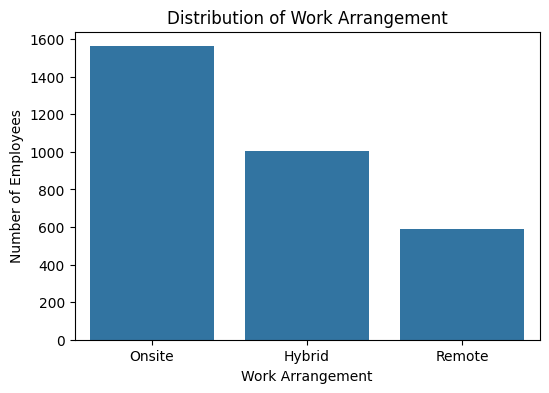

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Work_Arrangement")
plt.title("Distribution of Work Arrangement")
plt.xlabel("Work Arrangement")
plt.ylabel("Number of Employees")
plt.show()

**Columns Excluded from Clustering Analysis:**
- "Survey_Date"
- "Region"
- "Industry"
- "Job_Role"
- "Gender"
- "Age"
- "Salary_Range"

**Rationale:** These columns are not behavioral indicators of employee experience, productivity, or well-being. Including them in the clustering process could create clusters driven by identifiers rather than meaningful patterns.  

However, these variables can still be useful for post-clustering profiling.


# Data Cleaning

In [15]:
cleaned_df= df.copy().drop(columns=["Survey_Date", "Region", "Job_Role", "Industry", "Gender", "Age", "Salary_Range"])

### Encoding of Categorical Variables

**One-Hot Encoding for columns:**
- "Work_Arrangement"
- "Mental_Health_Status"
- "Physical_Health_Issues"

In [16]:
cleaned_df["work_onsite"] = 0
cleaned_df["work_hybrid"] = 0
cleaned_df["work_remote"] = 0

In [17]:
cleaned_df.loc[cleaned_df["Work_Arrangement"] == "Onsite","work_onsite"] = 1
cleaned_df.loc[cleaned_df["Work_Arrangement"] == "Hybrid","work_hybrid"] = 1
cleaned_df.loc[cleaned_df["Work_Arrangement"] == "Remote","work_remote"] = 1

In [18]:
cleaned_df.drop("Work_Arrangement", axis=1, inplace=True)

In [19]:
cleaned_df["has_Stress_Disorder"] = 0
cleaned_df["has_ADHD"] = 0
cleaned_df["has_Burnout"] = 0
cleaned_df["has_Anxiety"] = 0
cleaned_df["has_PTSD"] = 0
cleaned_df["has_Depression"] = 0

In [20]:
cleaned_df.loc[cleaned_df["Mental_Health_Status"] == "Stress Disorder", "has_Stress_Disorder"] = 1
cleaned_df.loc[cleaned_df["Mental_Health_Status"] == "ADHD", "has_ADHD"] = 1
cleaned_df.loc[cleaned_df["Mental_Health_Status"] == "Burnout", "has_Burnout"] = 1
cleaned_df.loc[cleaned_df["Mental_Health_Status"] == "Anxiety", "has_Anxiety"] = 1
cleaned_df.loc[cleaned_df["Mental_Health_Status"] == "PTSD","has_PTSD"] = 1
cleaned_df.loc[cleaned_df["Mental_Health_Status"] == "Depression", "has_Depression"] = 1

In [21]:
cleaned_df.drop("Mental_Health_Status", axis=1, inplace=True)

In [22]:
cleaned_df["has_Shoulder_Pain"] = 0
cleaned_df["has_Neck_Pain"] = 0
cleaned_df["has_Back_Pain"] = 0
cleaned_df["has_Eye_Strain"] = 0
cleaned_df["has_Wrist_Pain"] = 0

In [23]:
cleaned_df.loc[cleaned_df["Physical_Health_Issues"].str.contains("Shoulder Pain", regex=False, na=False), "has_Shoulder_Pain"] = 1
cleaned_df.loc[cleaned_df["Physical_Health_Issues"].str.contains("Neck Pain", regex=False, na=False), "has_Neck_Pain"] = 1
cleaned_df.loc[cleaned_df["Physical_Health_Issues"].str.contains("Back Pain", regex=False, na=False), "has_Back_Pain"] = 1
cleaned_df.loc[cleaned_df["Physical_Health_Issues"].str.contains("Eye Strain", regex=False, na=False), "has_Eye_Strain"] = 1
cleaned_df.loc[cleaned_df["Physical_Health_Issues"].str.contains("Wrist Pain",regex=False, na=False),"has_Wrist_Pain"] = 1

In [24]:
cleaned_df.drop("Physical_Health_Issues", axis=1, inplace=True)

In [25]:
cleaned_df.head()

,Hours_Per_Week,Burnout_Level,Work_Life_Balance_Score,Social_Isolation_Score,work_onsite,work_hybrid,work_remote,has_Stress_Disorder,has_ADHD,has_Burnout,has_Anxiety,has_PTSD,has_Depression,has_Shoulder_Pain,has_Neck_Pain,has_Back_Pain,has_Eye_Strain,has_Wrist_Pain
0,64,High,3,2,1,0,0,1,0,0,0,0,0,1,1,0,0,0
1,37,High,4,2,1,0,0,1,0,0,0,0,0,0,0,1,0,0
2,36,High,3,2,1,0,0,0,1,0,0,0,0,1,0,0,1,0
3,63,Medium,1,2,1,0,0,0,1,0,0,0,0,1,0,0,1,0
4,65,Medium,5,4,0,1,0,0,0,0,0,0,0,0,0,0,0,0


**Label Encoding of Ordinal Variable:**
- "Burnout_Level": Mapping (Low, Medium, High) into (1,2,3) respectively

In [26]:
burnout_encoding = {'Low': 1, 'Medium': 2, 'High': 3}
cleaned_df["Burnout_Level"] = cleaned_df["Burnout_Level"].map(burnout_encoding)

In [27]:
cleaned_df.head()

,Hours_Per_Week,Burnout_Level,Work_Life_Balance_Score,Social_Isolation_Score,work_onsite,work_hybrid,work_remote,has_Stress_Disorder,has_ADHD,has_Burnout,has_Anxiety,has_PTSD,has_Depression,has_Shoulder_Pain,has_Neck_Pain,has_Back_Pain,has_Eye_Strain,has_Wrist_Pain
0,64,3,3,2,1,0,0,1,0,0,0,0,0,1,1,0,0,0
1,37,3,4,2,1,0,0,1,0,0,0,0,0,0,0,1,0,0
2,36,3,3,2,1,0,0,0,1,0,0,0,0,1,0,0,1,0
3,63,2,1,2,1,0,0,0,1,0,0,0,0,1,0,0,1,0
4,65,2,5,4,0,1,0,0,0,0,0,0,0,0,0,0,0,0


### Standardization of Numerical Variables
- "Hours_Per_Week"
- "Burnout_Level"
- "Work_Life_Balance_Score"
- "Social_Isolation_Score"

In [28]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cleaned_df[["Hours_Per_Week", "Burnout_Level", "Work_Life_Balance_Score","Social_Isolation_Score"]])
scaled_data

array([[ 1.58437147,  1.21082339,  0.00299566, -0.59290285],
       [-1.45060178,  1.21082339,  0.86275015, -0.59290285],
       [-1.5630082 ,  1.21082339,  0.00299566, -0.59290285],
       ...,
       [ 1.02233938, -0.12761129, -1.71651333,  0.24835301],
       [ 0.23549447, -0.12761129,  0.00299566,  1.93086473],
       [-1.22578895, -0.12761129,  0.86275015, -0.59290285]],
      shape=(3157, 4))

In [29]:
scaled_data_df = pd.DataFrame(scaled_data,index=cleaned_df.index,columns=["Hours_Per_Week", "Burnout_Level", "Work_Life_Balance_Score","Social_Isolation_Score"])

scaled_data_df.head()

,Hours_Per_Week,Burnout_Level,Work_Life_Balance_Score,Social_Isolation_Score
0,1.58,1.21,0.00,-0.59
1,-1.45,1.21,0.86,-0.59
2,-1.56,1.21,0.00,-0.59
3,1.47,-0.13,-1.72,-0.59
4,1.70,-0.13,1.72,1.09


In [30]:
cleaned_df = cleaned_df.drop(columns=["Hours_Per_Week","Burnout_Level","Work_Life_Balance_Score","Social_Isolation_Score"])
cleaned_df.head()

,work_onsite,work_hybrid,work_remote,has_Stress_Disorder,has_ADHD,has_Burnout,has_Anxiety,has_PTSD,has_Depression,has_Shoulder_Pain,has_Neck_Pain,has_Back_Pain,has_Eye_Strain,has_Wrist_Pain
0,1,0,0,1,0,0,0,0,0,1,1,0,0,0
1,1,0,0,1,0,0,0,0,0,0,0,1,0,0
2,1,0,0,0,1,0,0,0,0,1,0,0,1,0
3,1,0,0,0,1,0,0,0,0,1,0,0,1,0
4,0,1,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
scaled_data_df.index = cleaned_df.index
preprocessed_df = pd.concat([cleaned_df, scaled_data_df], axis=1)

In [34]:
preprocessed_df.head()

,work_onsite,work_hybrid,work_remote,has_Stress_Disorder,has_ADHD,has_Burnout,has_Anxiety,has_PTSD,has_Depression,has_Shoulder_Pain,has_Neck_Pain,has_Back_Pain,has_Eye_Strain,has_Wrist_Pain,Hours_Per_Week,Burnout_Level,Work_Life_Balance_Score,Social_Isolation_Score
0,1,0,0,1,0,0,0,0,0,1,1,0,0,0,1.58,1.21,0.00,-0.59
1,1,0,0,1,0,0,0,0,0,0,0,1,0,0,-1.45,1.21,0.86,-0.59
2,1,0,0,0,1,0,0,0,0,1,0,0,1,0,-1.56,1.21,0.00,-0.59
3,1,0,0,0,1,0,0,0,0,1,0,0,1,0,1.47,-0.13,-1.72,-0.59
4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1.70,-0.13,1.72,1.09


In [32]:
preprocessed_df.shape

(3157, 18)

### Feature Engineering

**Encode work modality into an ordinal variable, based on autonomy:**
- 0 = onsite
- 1 = hybrid
- 2 = remote 

In [ ]:
preprocessed_df["Work_Modality_Score"] = (preprocessed_df["work_onsite"] * 0 + preprocessed_df["work_hybrid"] * 1 + preprocessed_df["work_remote"] * 2)

In [36]:
preprocessed_df.head()

,work_onsite,work_hybrid,work_remote,has_Stress_Disorder,has_ADHD,has_Burnout,has_Anxiety,has_PTSD,has_Depression,has_Shoulder_Pain,has_Neck_Pain,has_Back_Pain,has_Eye_Strain,has_Wrist_Pain,Hours_Per_Week,Burnout_Level,Work_Life_Balance_Score,Social_Isolation_Score,Work_Modality_Score
0,1,0,0,1,0,0,0,0,0,1,1,0,0,0,1.58,1.21,0.00,-0.59,0
1,1,0,0,1,0,0,0,0,0,0,0,1,0,0,-1.45,1.21,0.86,-0.59,0
2,1,0,0,0,1,0,0,0,0,1,0,0,1,0,-1.56,1.21,0.00,-0.59,0
3,1,0,0,0,1,0,0,0,0,1,0,0,1,0,1.47,-0.13,-1.72,-0.59,0
4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1.70,-0.13,1.72,1.09,1


Construct **Work_Modality_Intensity** column by averaging:
- where work happens: "Work_Modality_Score"
- how much work happens: "Hours_Per_Week"

In [ ]:
preprocessed_df["Work_Modality_Intensity"] = (preprocessed_df[["Work_Modality_Score", "Hours_Per_Week"]].mean(axis=1))

In [39]:
preprocessed_df.drop(columns=["work_onsite","work_hybrid","work_remote","Hours_Per_Week","Work_Modality_Score"],inplace=True)


In [40]:
preprocessed_df.head()

,has_Stress_Disorder,has_ADHD,has_Burnout,has_Anxiety,has_PTSD,has_Depression,has_Shoulder_Pain,has_Neck_Pain,has_Back_Pain,has_Eye_Strain,has_Wrist_Pain,Burnout_Level,Work_Life_Balance_Score,Social_Isolation_Score,Work_Modality_Intensity
0,1,0,0,0,0,0,1,1,0,0,0,1.21,0.00,-0.59,0.79
1,1,0,0,0,0,0,0,0,1,0,0,1.21,0.86,-0.59,-0.73
2,0,1,0,0,0,0,1,0,0,1,0,1.21,0.00,-0.59,-0.78
3,0,1,0,0,0,0,1,0,0,1,0,-0.13,-1.72,-0.59,0.74
4,0,0,0,0,0,0,0,0,0,0,0,-0.13,1.72,1.09,1.35


**Encode mental health as an ordinal severity score**
- 0 = No issue
- 1 = Stress disorder/ADHD
- 2 = Anxiety
- 3 = Burnout
- 4 = Depression/PTSD

In [ ]:
preprocessed_df['Mental_Health_Severity_Score'] = (preprocessed_df['has_Stress_Disorder'] * 1 +preprocessed_df['has_ADHD'] * 1 +preprocessed_df['has_Anxiety'] * 2 +
preprocessed_df['has_Burnout'] * 3 + preprocessed_df['has_Depression'] * 4 + preprocessed_df['has_PTSD'] * 4)

In [51]:
preprocessed_df.drop(columns=["has_Stress_Disorder", "has_ADHD", "has_Burnout","has_Anxiety", "has_PTSD", "has_Depression"],inplace=True)

In [52]:
preprocessed_df.head()

,has_Shoulder_Pain,has_Neck_Pain,has_Back_Pain,has_Eye_Strain,has_Wrist_Pain,Burnout_Level,Work_Life_Balance_Score,Social_Isolation_Score,Work_Modality_Intensity,Mental_Health_Severity_Score,Physical_Strain_Score
0,1,1,0,0,0,1.21,0.00,-0.59,0.79,1,2
1,0,0,1,0,0,1.21,0.86,-0.59,-0.73,1,1
2,1,0,0,1,0,1.21,0.00,-0.59,-0.78,1,2
3,1,0,0,1,0,-0.13,-1.72,-0.59,0.74,1,2
4,0,0,0,0,0,-0.13,1.72,1.09,1.35,0,0


**Construct physical health strain score**

By accumulation

In [49]:
Physical_Health_Issues=["has_Shoulder_Pain", "has_Neck_Pain", "has_Back_Pain","has_Eye_Strain", "has_Wrist_Pain"]

preprocessed_df["Physical_Strain_Score"]=preprocessed_df[Physical_Health_Issues].sum(axis=1)

In [53]:
preprocessed_df.drop(columns=Physical_Health_Issues,inplace=True)

In [54]:
preprocessed_df.head()

,Burnout_Level,Work_Life_Balance_Score,Social_Isolation_Score,Work_Modality_Intensity,Mental_Health_Severity_Score,Physical_Strain_Score
0,1.21,0.00,-0.59,0.79,1,2
1,1.21,0.86,-0.59,-0.73,1,1
2,1.21,0.00,-0.59,-0.78,1,2
3,-0.13,-1.72,-0.59,0.74,1,2
4,-0.13,1.72,1.09,1.35,0,0


Construct **Psychophysiological_Health_Strain_Score** column by averaging:
- "Mental_Health_Severity_Score"
- "Physical_Strain_Score"

In [56]:
preprocessed_df['Psychophysiological_Health_Strain_Score'] = (preprocessed_df[['Mental_Health_Severity_Score', 'Physical_Strain_Score']].mean(axis=1))


In [59]:
preprocessed_df.drop(columns=["Mental_Health_Severity_Score","Physical_Strain_Score"],inplace=True)

In [60]:
preprocessed_df.head()

,Burnout_Level,Work_Life_Balance_Score,Social_Isolation_Score,Work_Modality_Intensity,Psychophysiological_Health_Strain_Score
0,1.21,0.00,-0.59,0.79,1.50
1,1.21,0.86,-0.59,-0.73,1.00
2,1.21,0.00,-0.59,-0.78,1.50
3,-0.13,-1.72,-0.59,0.74,1.50
4,-0.13,1.72,1.09,1.35,0.00


**Invert Work_Life_Balance_Score**

From (higher=better) to (higher=worse)

In [ ]:
preprocessed_df["Work_Life_Balance_Score_Inverted"] = preprocessed_df["Work_Life_Balance_Score"] * -1


In [62]:
preprocessed_df["Perceived_WellBeing_SocialIndex"] = preprocessed_df[["Burnout_Level", "Work_Life_Balance_Score_Inverted", "Social_Isolation_Score"]].mean(axis=1)


In [64]:
preprocessed_df.drop(columns=["Burnout_Level", "Work_Life_Balance_Score", "Work_Life_Balance_Score_Inverted", "Social_Isolation_Score"],inplace=True)


In [65]:
preprocessed_df.head()

,Work_Modality_Intensity,Psychophysiological_Health_Strain_Score,Perceived_WellBeing_SocialIndex
0,0.79,1.50,0.20
1,-0.73,1.00,-0.08
2,-0.78,1.50,0.20
3,0.74,1.50,0.33
4,1.35,0.00,-0.25


**Features Rescaling after Engineering**

In [66]:
scaler = StandardScaler()
final_data = scaler.fit_transform(preprocessed_df[["Work_Modality_Intensity", "Psychophysiological_Health_Strain_Score","Perceived_WellBeing_SocialIndex"]])
final_data

array([[ 0.71059562, -0.41090342,  0.34747134],
       [-1.70474484, -0.94452008, -0.13834417],
       [-1.79420189, -0.41090342,  0.34747134],
       ...,
       [ 0.26331035,  0.6563299 ,  1.03816498],
       [-0.36288903,  1.72356322,  1.01725919],
       [-1.52583073,  0.6563299 , -0.89464418]], shape=(3157, 3))

In [67]:
final_df = pd.DataFrame(final_data,index=preprocessed_df.index,columns=["Work_Modality_Intensity", "Psychophysiological_Health_Strain_Score","Perceived_WellBeing_SocialIndex"])
final_df.head()

,Work_Modality_Intensity,Psychophysiological_Health_Strain_Score,Perceived_WellBeing_SocialIndex
0,0.71,-0.41,0.35
1,-1.70,-0.94,-0.14
2,-1.79,-0.41,0.35
3,0.62,-0.41,0.56
4,1.60,-2.01,-0.43


### Clustering

**Choosing the optimal K using Elbow Method**

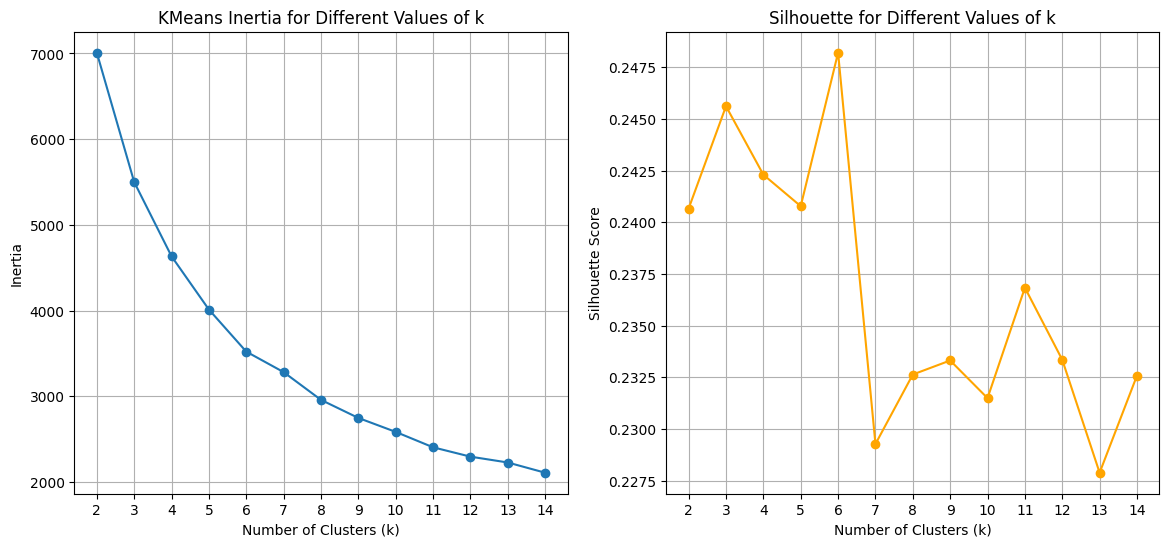

In [69]:
max_k=14 

inertia=[]
silhouette_scores=[]
k_values=range(2,max_k + 1)  

for k in k_values:
    kmeans= KMeans(n_clusters=k, random_state=42,max_iter=1000) 

    cluster_labels=kmeans.fit_predict(final_df) 
    sil_score= silhouette_score(final_df,cluster_labels)
    silhouette_scores.append(sil_score)
    inertia.append(kmeans.inertia_) 

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.plot(k_values,inertia,marker='o')
plt.title('KMeans Inertia for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(k_values,silhouette_scores,marker='o',color='orange')
plt.title('Silhouette for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)

plt.show()

**Selected k = 3 as the optimal number of clusters**

- **Elbow Method:** The inertia graph shows a clear point of stability at k = 3.
- **Silhouette Score:** The silhouette score graph peaks around k = 3.


In [70]:
kmeans=KMeans(n_clusters=3,random_state=42,max_iter=1000)

cluster_labels=kmeans.fit_predict(final_df)

cluster_labels

array([0, 1, 1, ..., 0, 2, 2], shape=(3157,), dtype=int32)

In [73]:
final_df["Cluster"].unique()

array([0, 1, 2], dtype=int32)

**Add "Cluster" Column**

In [71]:
final_df["Cluster"]=cluster_labels

In [72]:
final_df.head(10)

,Work_Modality_Intensity,Psychophysiological_Health_Strain_Score,Perceived_WellBeing_SocialIndex,Cluster
0,0.71,-0.41,0.35,0
1,-1.70,-0.94,-0.14,1
2,-1.79,-0.41,0.35,1
3,0.62,-0.41,0.56,0
4,1.60,-2.01,-0.43,0
5,0.44,0.66,-0.42,2
6,0.53,-0.41,-0.89,1
7,-0.09,-0.94,0.35,1
8,0.78,-0.41,1.03,0
9,-0.09,0.12,-1.86,1


**3D Visualization of Clusters:**  

- **X-axis:** Work Modality Intensity  
- **Y-axis:** Psychophysiological Health Strain Score  
- **Z-axis:** Perceived Well-Being Social Index  


- Cluster 0 – Blue 
- Cluster 1 – Green 
- Cluster 2 – Red   


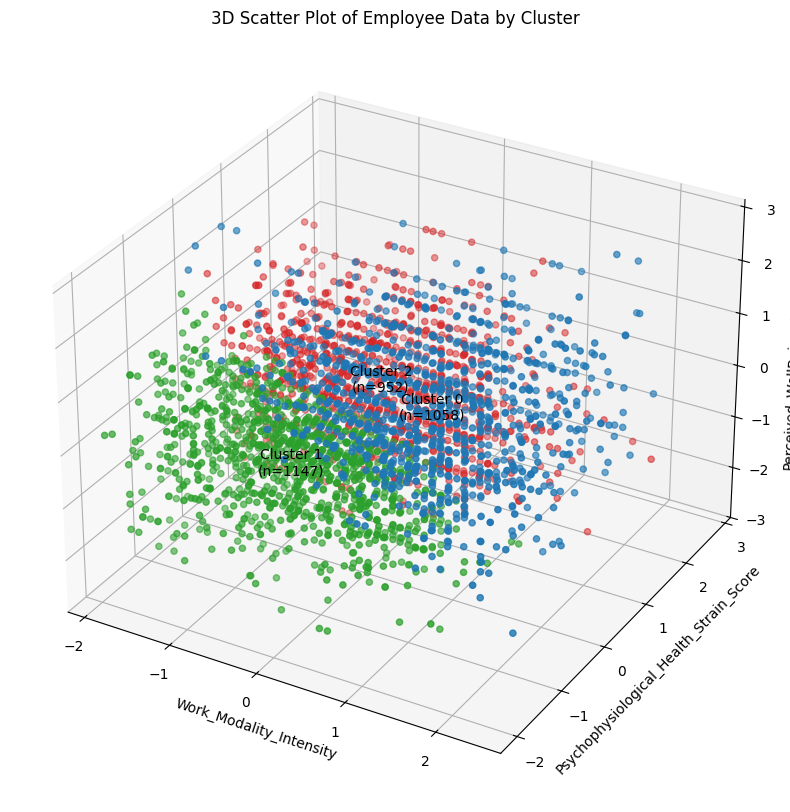

In [80]:

cluster_colors = {
    0: '#1f77b4',
    1: '#2ca02c',
    2: '#d62728'
}

colors = final_df['Cluster'].map(cluster_colors)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(
    final_df['Work_Modality_Intensity'],
    final_df['Psychophysiological_Health_Strain_Score'],
    final_df['Perceived_WellBeing_SocialIndex'],
    c=colors,
    marker='o'
)


for cluster_id, color in cluster_colors.items():
    cluster_data = final_df[final_df['Cluster'] == cluster_id]
    
    # centroids
    x_mean = cluster_data['Work_Modality_Intensity'].mean()
    y_mean = cluster_data['Psychophysiological_Health_Strain_Score'].mean()
    z_mean = cluster_data['Perceived_WellBeing_SocialIndex'].mean()
    
    count = len(cluster_data)
    
    ax.text(
        x_mean, y_mean, z_mean,
        f'Cluster {cluster_id}\n(n={count})',
        color='black',
        fontsize=10,
        ha='center',
        va='center'
    )

ax.set_xlabel('Work_Modality_Intensity')
ax.set_ylabel('Psychophysiological_Health_Strain_Score')
ax.set_zlabel('Perceived_WellBeing_SocialIndex')
ax.set_title('3D Scatter Plot of Employee Data by Cluster')

plt.show()


**Visualization of Distribution of Features by Cluster**  

Using violin plots


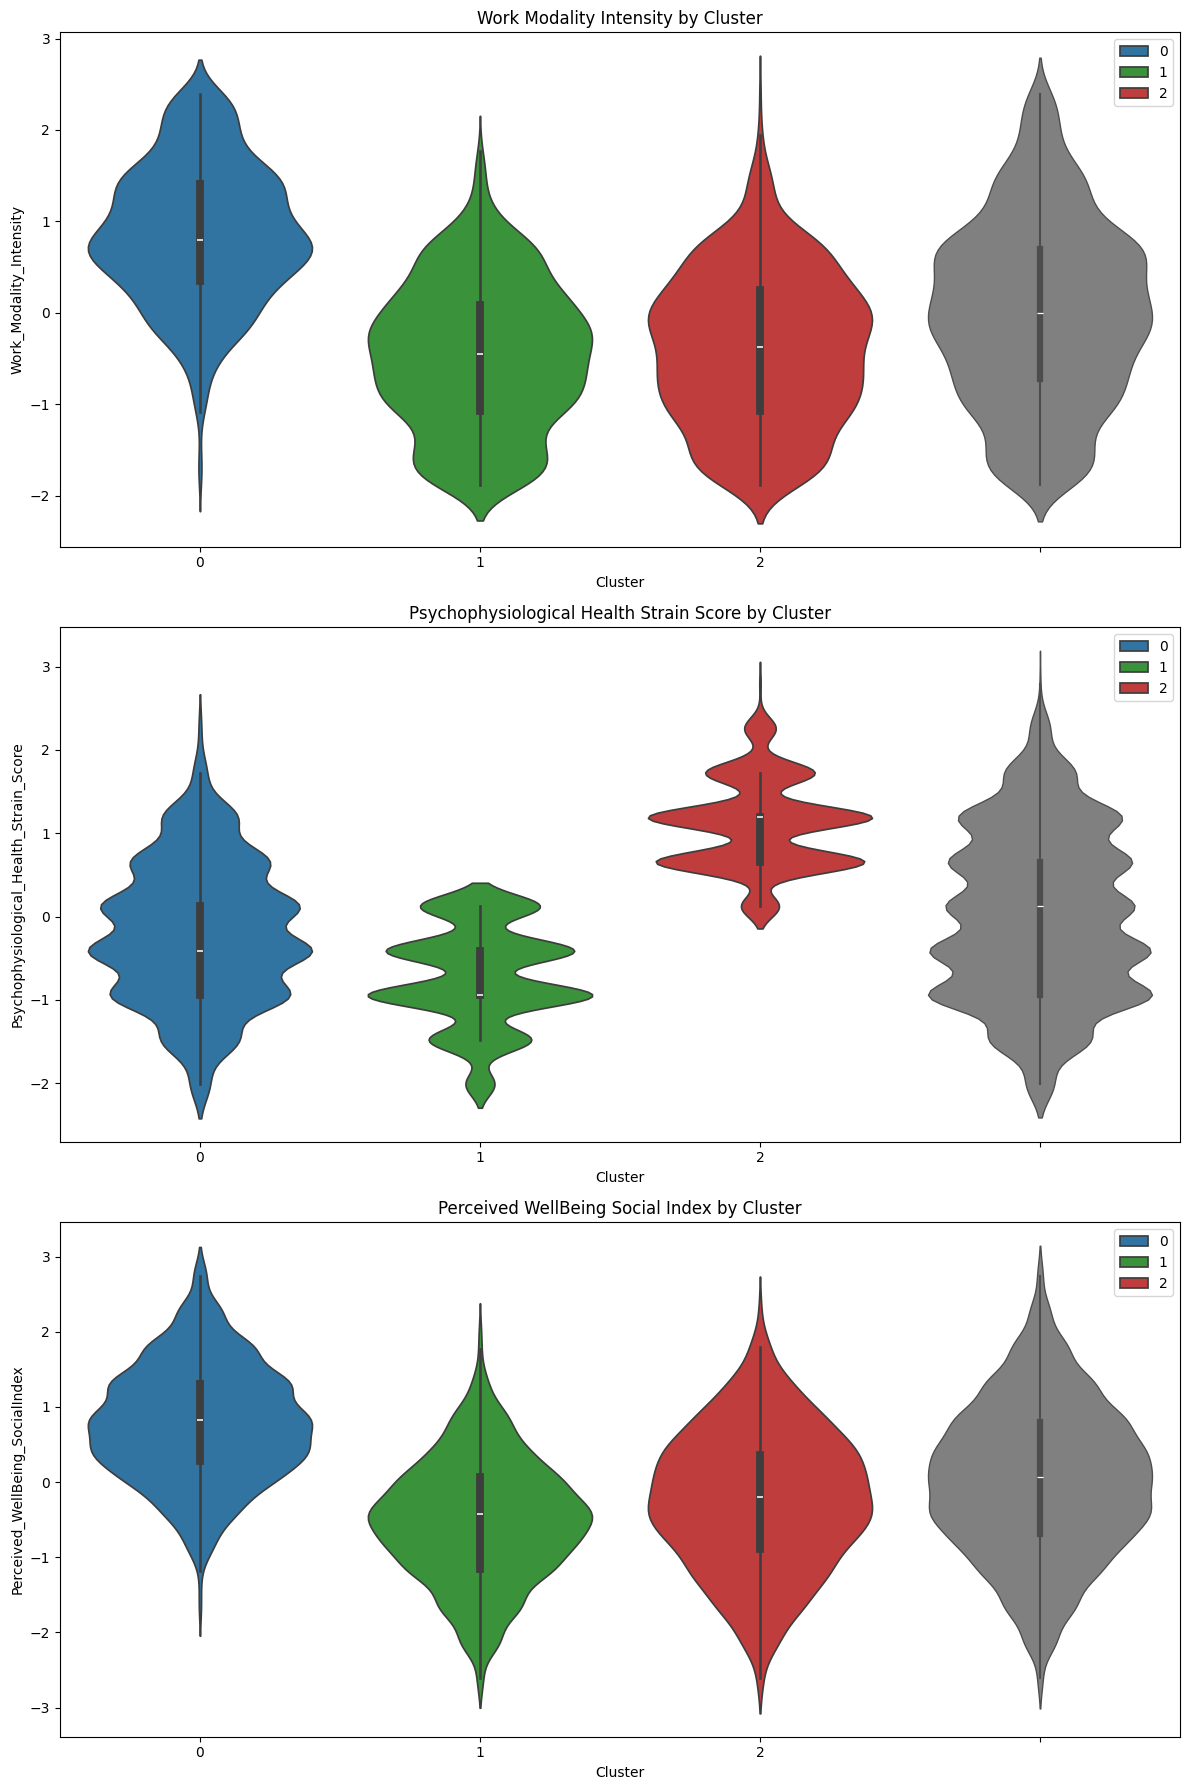

In [81]:
plt.figure(figsize=(12,18))

plt.subplot(3,1,1)
sns.violinplot(x=final_df['Cluster'],y=final_df['Work_Modality_Intensity'],palette=cluster_colors, hue=final_df['Cluster'])
sns.violinplot(y=final_df['Work_Modality_Intensity'],color='gray',linewidth=1.0)
plt.title('Work Modality Intensity by Cluster')
plt.ylabel('Work_Modality_Intensity')

plt.subplot(3,1,2)
sns.violinplot(x=final_df['Cluster'],y=final_df['Psychophysiological_Health_Strain_Score'],palette=cluster_colors, hue=final_df['Cluster'])
sns.violinplot(y=final_df['Psychophysiological_Health_Strain_Score'],color='gray',linewidth=1.0)
plt.title('Psychophysiological Health Strain Score by Cluster')
plt.ylabel('Psychophysiological_Health_Strain_Score')

plt.subplot(3,1,3)
sns.violinplot(x=final_df['Cluster'],y=final_df['Perceived_WellBeing_SocialIndex'],palette=cluster_colors, hue=final_df['Cluster'])
sns.violinplot(y=final_df['Perceived_WellBeing_SocialIndex'],color='gray',linewidth=1.0)
plt.title('Perceived WellBeing Social Index by Cluster')
plt.ylabel('Perceived_WellBeing_SocialIndex')

plt.tight_layout()
plt.show()

# Resulted Clusters:

**Cluster 0: Thriving**

**Rationale:** This cluster represents the most optimal balance of high performance and personal health. These individuals maintain the highest work modality intensity and the highest social wellbeing, yet they exhibit a low psychophysiological health strain score.

**Cluster 1: Detached**

**Rationale:** This group is characterized by a lack of engagement across all measured dimensions. They exhibit the lowest work modality intensity and low social wellbeing. However, because they are under very little pressure, they also maintain the lowest and most stable health strain score.

**Cluster 2: Vulnerable**

**Rationale:** This is the high-risk group within the dataset. Despite having only moderate work intensity, they suffer from the highest health strain score, with a distribution that peaks significantly higher than the others. When combined with their low social wellbeing, it indicates they lack the social resources to cope with even average work demands, making them highly susceptible to burnout.

### Mapping out the Clusters

In [82]:
cluster_labels={0:"Thriving",1:"Detached",2:"Vulnerable"}
final_df["Cluster_Label"]=final_df["Cluster"].map(cluster_labels)

In [83]:
final_df.head()

,Work_Modality_Intensity,Psychophysiological_Health_Strain_Score,Perceived_WellBeing_SocialIndex,Cluster,Cluster_Label
0,0.71,-0.41,0.35,0,Thriving
1,-1.70,-0.94,-0.14,1,Detached
2,-1.79,-0.41,0.35,1,Detached
3,0.62,-0.41,0.56,0,Thriving
4,1.60,-2.01,-0.43,0,Thriving
